In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score
from sklearn.tree import (DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from matplotlib.pyplot import subplots
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
from sklearn.ensemble import GradientBoostingRegressor as GBR
import seaborn as sns

In [5]:
airbnb_data = "C:\\Users\\rache\\Downloads\\cse2600\\airbnb_data\\Airbnb_data_cleaned2.csv" #path for csv

df = pd.read_csv(airbnb_data) #read in the data

In [6]:
df_city1  = df[(df["city"] == 1)  & (df["price_outlier"] == 0)]  # Toronto
df_city2  = df[(df["city"] == 2)  & (df["price_outlier"] == 0)]  # NewYork
df_city3  = df[(df["city"] == 3)  & (df["price_outlier"] == 0)]  # Amsterdam
df_city4  = df[(df["city"] == 4)  & (df["price_outlier"] == 0)]  # Berlin
df_city5  = df[(df["city"] == 5)  & (df["price_outlier"] == 0)]  # Dublin
df_city6  = df[(df["city"] == 6)  & (df["price_outlier"] == 0)]  # Hongkong
df_city7  = df[(df["city"] == 7)  & (df["price_outlier"] == 0)]  # Munich
df_city8  = df[(df["city"] == 8)  & (df["price_outlier"] == 0)]  # Singapore
df_city9  = df[(df["city"] == 9)  & (df["price_outlier"] == 0)]  # Sydney
df_city10 = df[(df["city"] == 10) & (df["price_outlier"] == 0)]  # Tokyo
df_city11 = df[(df["city"] == 11) & (df["price_outlier"] == 0)]  # Taipei

In [28]:
df_city11["area"].value_counts()

area
3    4605
Name: count, dtype: int64

In [7]:
city_groups = {
    1: ("df_city1", df_city1, "Toronto"),
    2: ("df_city2", df_city2, "NewYork"),
    3: ("df_city3", df_city3, "Amsterdam"),
    4: ("df_city4", df_city4, "Berlin"),
    5: ("df_city5", df_city5, "Dublin"),
    6: ("df_city6", df_city6, "Hongkong"),
    7: ("df_city7", df_city7, "Munich"),
    8: ("df_city8", df_city8, "Singapore"),
    9: ("df_city9", df_city9, "Sydney"),
    10: ("df_city10", df_city10, "Tokyo"),
    11: ("df_city11", df_city11, "Taipei")
}



===== Toronto =====


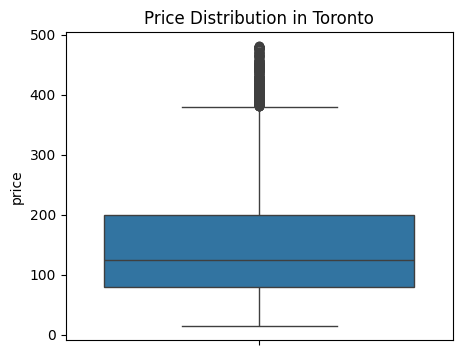


===== NewYork =====


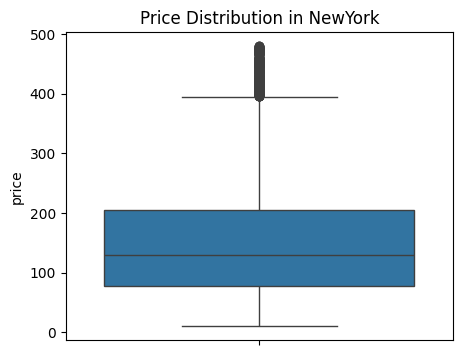


===== Amsterdam =====


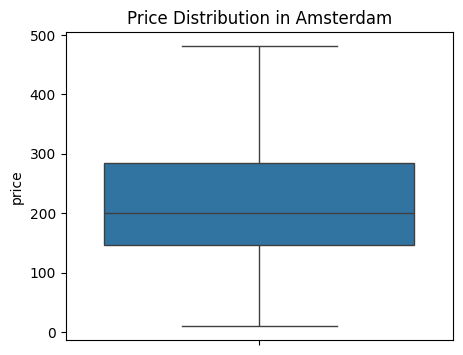


===== Berlin =====


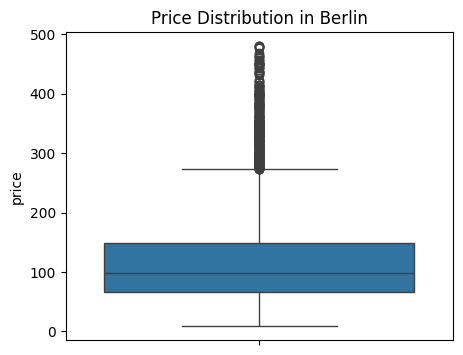


===== Dublin =====


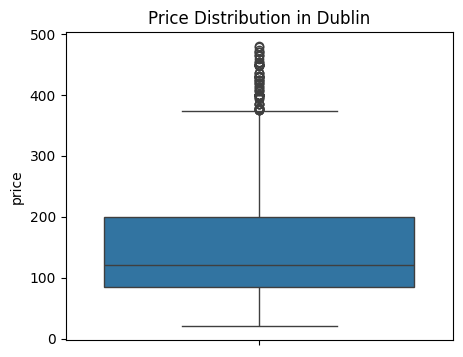


===== Hongkong =====


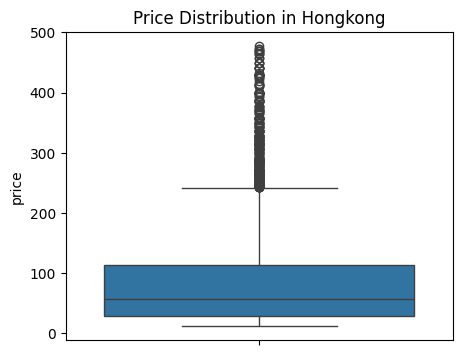


===== Munich =====


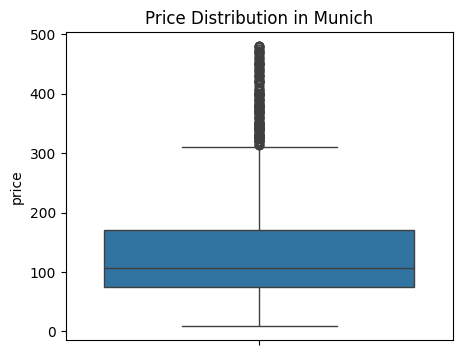


===== Singapore =====


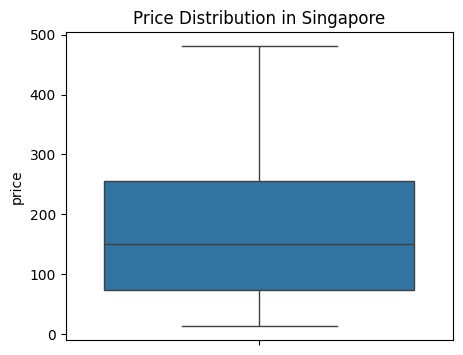


===== Sydney =====


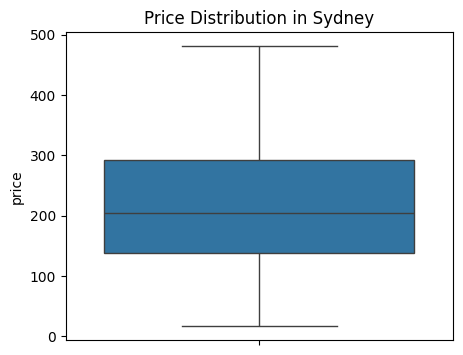


===== Tokyo =====


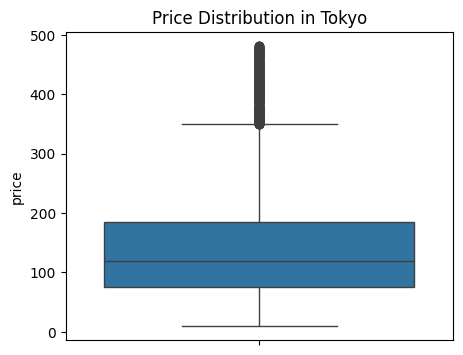


===== Taipei =====


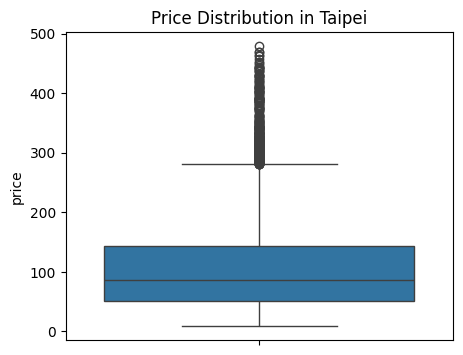

In [8]:
for city_id, (name, df_city, city_label) in city_groups.items():

    print(f"\n===== {city_label} =====")

    # Boxplot for price
    plt.figure(figsize=(5,4))
    sns.boxplot(y=df_city['price'])
    plt.title(f"Price Distribution in {city_label}")
    plt.show()


In [9]:
results_city = {}


for city_id, (name, df_city, city_label) in city_groups.items():

    train, test = train_test_split(df_city, train_size=(int(len(df_city)*0.8)), random_state=20)

    # Split data into features (X) and target (y) for training and testing
    y_train = train['price']
    X_train = train.drop(['price'], axis=1)
    y_test = test['price']
    X_test = test.drop(['price'], axis=1)

    model = RandomForestRegressor(n_estimators=200, random_state=22, max_depth=None, max_features= 'sqrt', min_samples_leaf=1, min_samples_split=2)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2_rf = r2_score(y_test, y_pred)
    mse_rf = mean_squared_error(y_test, y_pred)

    results_city[city_label] = {
        "MSE": mse_rf,
        "R²": r2_rf
    }
    #print(city_label, "Random Forest MSE:", round(mse_rf, 2))
    #print(city_label, "Random Forest R²:", round(r2_rf, 3))
    print(city_label)
    feature_names = list(X_train.columns)
    importances = model.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    feature_imp = pd.DataFrame(
        {'importance':model.feature_importances_},
        index=feature_names)
    feature_imp_sorted = feature_imp.sort_values(by='importance', ascending=False)
    display(feature_imp_sorted)

# Summary table of all cities
pd.DataFrame(results_city).T

Toronto


,importance
accommodates,0.152185
host since,0.109064
room_type,0.104234
bedrooms,0.101719
sales,0.097147
total reviewers number,0.090814
bathrooms,0.074068
beds,0.068602
host acceptance rate,0.055314
host total listings count,0.052882


NewYork


,importance
room_type,0.135648
host since,0.133838
accommodates,0.114524
sales,0.102691
listing number,0.089573
host total listings count,0.076419
total reviewers number,0.073481
host acceptance rate,0.067138
beds,0.062255
bedrooms,0.051090


Amsterdam


...

Tokyo


,importance
accommodates,0.211485
beds,0.110779
bedrooms,0.109999
host since,0.105079
sales,0.096283
total reviewers number,0.081953
listing number,0.068794
host total listings count,0.065176
host acceptance rate,0.042486
room_type,0.038978


Taipei


,importance
accommodates,0.245863
beds,0.150904
room_type,0.102215
host since,0.094363
sales,0.085346
host acceptance rate,0.078523
host total listings count,0.066513
listing number,0.066507
total reviewers number,0.063052
host response rate,0.032558


,MSE,R²
Toronto,4159.228000,0.523753
NewYork,4515.871995,0.567624
Amsterdam,5305.486322,0.481398
Berlin,2762.641510,0.566040
Dublin,3780.814898,0.597133
Hongkong,1645.206888,0.729688
Munich,4821.067153,0.419535
Singapore,3576.688728,0.720494
Sydney,4772.131210,0.551649
Tokyo,3415.590833,0.591301
